## Constrained Adversarial Attack Implementation
This notebook implements constrained adversarial attacks against all three disease prediction models.
We use two attack strategies chosen deliberately based on model architecture:

| Model | Architecture | Attack Strategy | Rationale |
|-------|-------------|-----------------|----------|
| Heart Disease | Logistic Regression (C=0.1) | Analytical Minimal Perturbation | LR has a closed-form decision boundary i.e. exact solution exists |
| Stroke | Logistic Regression (C=0.01) | Analytical Minimal Perturbation | Same architecture, stricter sparsity |
| Diabetes | Random Forest | HopSkipJump (ART, black-box) | Tree ensembles have no closed-form boundary hence black-box attack required |

**Threat model:** Black-box adversary, targeted attack (High Risk → Low Risk), clinically constrained inputs.

**All attacks are post-processed through `apply_constraints_to_array()` from 12_clinical_plausibility**

**Key research question:** Does stricter L1 regularisation (C=0.01 vs C=0.1) meaningfully reduce adversarial vulnerability through feature sparsity?

**Interpretation caution:** Cross-disease ASR and L2 comparisons are descriptive only because the attack families differ across models. The cleaner architecture-level comparison in this notebook is Heart LR vs Stroke LR.

In [1]:
import json
import sys
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
OUTPUT_DIR = ROOT / 'output'
DATA_DIR = ROOT / 'data' / 'processed'

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')

print(f'Notebook dir: {NOTEBOOK_DIR}')
print(f'Project root: {ROOT}')
print(f'Output dir  : {OUTPUT_DIR}')
print(f'Data dir    : {DATA_DIR}')


Notebook dir: /home/iaminspiredbro/my_projects/xai-health-risk-system/notebooks
Project root: /home/iaminspiredbro/my_projects/xai-health-risk-system
Output dir  : /home/iaminspiredbro/my_projects/xai-health-risk-system/output
Data dir    : /home/iaminspiredbro/my_projects/xai-health-risk-system/data/processed


In [2]:
DIABETES_FEATURES = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]
DIABETES_TARGET = 'Outcome'
DIABETES_LOG_FEATURES = ['Insulin', 'DiabetesPedigreeFunction', 'Age']
DIABETES_WINSORIZE_FEATURES = ['Pregnancies', 'Glucose', 'SkinThickness', 'BMI']

HEART_FEATURES = [
    'Age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'
]
HEART_TARGET = 'target'
HEART_LOG_FEATURES = ['oldpeak', 'chol']

STROKE_RAW_FEATURES = [
    'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
    'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status'
]
STROKE_TARGET = 'stroke'
STROKE_MODEL_CATEGORICAL = ['gender', 'ever_married', 'work_type', 'smoking_status']
STROKE_MODEL_NUMERICAL = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
STROKE_LOG_FEATURES = ['avg_glucose_level', 'bmi']

N_ATTACK = 50
RNG = np.random.default_rng(42)


In [3]:
diabetes_model = joblib.load(OUTPUT_DIR / 'diabetes_rf_model.joblib')
diabetes_scaler = joblib.load(OUTPUT_DIR / 'diabetes_rf_scaler.joblib')

heart_model = joblib.load(OUTPUT_DIR / 'heart_disease_lasso_model.joblib')
heart_scaler = joblib.load(OUTPUT_DIR / 'heart_disease_scaler.joblib')

stroke_model = joblib.load(OUTPUT_DIR / 'stroke_model.joblib')
stroke_scaler = joblib.load(OUTPUT_DIR / 'stroke_scaler.joblib')
stroke_encoder = joblib.load(OUTPUT_DIR / 'stroke_encoder.joblib')
stroke_encoded_feature_names = list(
    stroke_encoder.get_feature_names_out(STROKE_MODEL_CATEGORICAL)
)

with open(OUTPUT_DIR / 'clinical_constraints.json', 'r') as f:
    constraints_raw = json.load(f)

with open(OUTPUT_DIR / 'diabetes_winsorize_bounds.json', 'r') as f:
    diabetes_winsorize_bounds = json.load(f)
    
print('Artifacts loaded successfully.')
print('Stroke encoded feature names:', stroke_encoded_feature_names)


Artifacts loaded successfully.
Stroke encoded feature names: ['gender_Male', 'gender_Other', 'ever_married_Yes', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


In [4]:
@dataclass
class FeatureConstraint:
    name: str
    min_val: Optional[float]
    max_val: Optional[float]
    mutable: bool
    is_categorical: bool
    allowed_values: Optional[List]
    clinical_source: str
    notes: str = ''

    def validate(self, value) -> bool:
        if self.is_categorical and self.allowed_values is not None:
            return value in self.allowed_values
        if self.min_val is not None and value < self.min_val:
            return False
        if self.max_val is not None and value > self.max_val:
            return False
        return True


def build_constraints_map(raw_constraints: dict, disease: str, feature_order: List[str]) -> Dict[str, FeatureConstraint]:
    by_name = {
        item['name']: FeatureConstraint(
            name=item['name'],
            min_val=item.get('min_val'),
            max_val=item.get('max_val'),
            mutable=item.get('mutable', True),
            is_categorical=item.get('is_categorical', False),
            allowed_values=item.get('allowed_values'),
            clinical_source=item.get('clinical_source', ''),
            notes=item.get('notes', ''),
        )
        for item in raw_constraints[disease]
    }
    return {name: by_name[name] for name in feature_order if name in by_name}


def restrict_constraints_to_encoder_categories(
    constraints: Dict[str, FeatureConstraint],
    categorical_features: List[str],
    encoder,
) -> Dict[str, FeatureConstraint]:
    encoder_categories = {
        feat: set(categories.tolist() if hasattr(categories, 'tolist') else categories)
        for feat, categories in zip(categorical_features, encoder.categories_)
    }

    for feat in categorical_features:
        constraint = constraints.get(feat)
        if constraint is None or not constraint.is_categorical or constraint.allowed_values is None:
            continue

        original_allowed = list(constraint.allowed_values)
        supported_allowed = [value for value in original_allowed if value in encoder_categories[feat]]
        dropped_allowed = [value for value in original_allowed if value not in encoder_categories[feat]]

        constraint.allowed_values = supported_allowed
        if dropped_allowed:
            print(f"Filtered unsupported stroke constraint values for {feat}: {dropped_allowed}")

    return constraints


diabetes_constraints = build_constraints_map(constraints_raw, 'diabetes', DIABETES_FEATURES)
heart_constraints = build_constraints_map(constraints_raw, 'heart', HEART_FEATURES)
stroke_constraints = build_constraints_map(constraints_raw, 'stroke', STROKE_RAW_FEATURES)
stroke_constraints = restrict_constraints_to_encoder_categories(
    stroke_constraints,
    STROKE_MODEL_CATEGORICAL,
    stroke_encoder,
)


def project_categorical(value, original, allowed_values):
    if allowed_values is None:
        return original
    if value in allowed_values:
        return value

    numeric_allowed = all(isinstance(v, (int, float, np.integer, np.floating)) for v in allowed_values)
    if numeric_allowed and isinstance(value, (int, float, np.integer, np.floating)):
        return min(allowed_values, key=lambda v: abs(float(v) - float(value)))

    return original


def apply_constraints_to_row(candidate: dict, original: dict, constraints: Dict[str, FeatureConstraint]) -> dict:
    constrained = dict(candidate)

    for feat, constraint in constraints.items():
        if feat not in candidate:
            continue

        orig_val = original.get(feat)
        cand_val = candidate.get(feat)

        if not constraint.mutable:
            constrained[feat] = orig_val
            continue

        if constraint.is_categorical:
            constrained[feat] = project_categorical(cand_val, orig_val, constraint.allowed_values)
            continue

        val = float(cand_val)
        if constraint.min_val is not None:
            val = max(val, constraint.min_val)
        if constraint.max_val is not None:
            val = min(val, constraint.max_val)
        constrained[feat] = val

    return constrained


def build_delta_vector(original: dict, adversarial: dict, feature_order: List[str], constraints: Dict[str, FeatureConstraint]) -> np.ndarray:
    deltas = []
    for feat in feature_order:
        constraint = constraints[feat]
        orig_val = original[feat]
        adv_val = adversarial[feat]
        if constraint.is_categorical:
            deltas.append(float(orig_val != adv_val))
        else:
            deltas.append(float(adv_val) - float(orig_val))
    return np.array(deltas, dtype=float)


print('Constraint utilities ready.')


Filtered unsupported stroke constraint values for work_type: ['children']
Constraint utilities ready.


In [5]:
def apply_diabetes_winsorization(df: pd.DataFrame) -> pd.DataFrame:
    X = df.copy()
    for col in DIABETES_WINSORIZE_FEATURES:
        bounds = diabetes_winsorize_bounds[col]
        X[col] = X[col].clip(lower=bounds['lower'], upper=bounds['upper'])
    return X


def preprocess_diabetes_raw(df: pd.DataFrame) -> np.ndarray:
    X = df[DIABETES_FEATURES].copy()
    X = apply_diabetes_winsorization(X)
    for col in DIABETES_LOG_FEATURES:
        X[col] = np.log1p(X[col].astype(float))
    return diabetes_scaler.transform(X)

def inverse_diabetes_model_space(X_model: np.ndarray) -> pd.DataFrame:
    X_raw = pd.DataFrame(diabetes_scaler.inverse_transform(np.asarray(X_model)), columns=DIABETES_FEATURES)
    for col in DIABETES_LOG_FEATURES:
        X_raw[col] = np.expm1(X_raw[col])
    return X_raw


def preprocess_heart_raw(df: pd.DataFrame) -> np.ndarray:
    X = df[HEART_FEATURES].copy()
    for col in HEART_LOG_FEATURES:
        X[col] = np.log1p(X[col].astype(float))
    return heart_scaler.transform(X)


def validate_stroke_categories(df: pd.DataFrame) -> None:
    for feat, categories in zip(STROKE_MODEL_CATEGORICAL, stroke_encoder.categories_):
        valid_values = set(categories.tolist() if hasattr(categories, 'tolist') else categories)
        unknown_values = sorted({value for value in df[feat].dropna().tolist() if value not in valid_values})
        if unknown_values:
            raise ValueError(
                f"Unknown categories {unknown_values} for stroke feature '{feat}'. "
                f"Supported values from fitted encoder: {sorted(valid_values)}"
            )


def preprocess_stroke_raw(df: pd.DataFrame) -> np.ndarray:
    X = df[STROKE_RAW_FEATURES].copy()
    num = X[STROKE_MODEL_NUMERICAL].copy()
    for col in STROKE_LOG_FEATURES:
        num[col] = np.log1p(num[col].astype(float))

    validate_stroke_categories(X)
    encoded = stroke_encoder.transform(X[STROKE_MODEL_CATEGORICAL])
    encoded_df = pd.DataFrame(encoded, columns=stroke_encoded_feature_names, index=X.index)
    X_processed = pd.concat([num, encoded_df], axis=1)
    return stroke_scaler.transform(X_processed)


def predict_from_raw(model, preprocess_fn, df: pd.DataFrame) -> np.ndarray:
    return model.predict(preprocess_fn(df))


def predict_proba_from_raw(model, preprocess_fn, df: pd.DataFrame) -> np.ndarray:
    return model.predict_proba(preprocess_fn(df))[:, 1]


def margin_from_raw(model, preprocess_fn, row: dict) -> float:
    X_model = preprocess_fn(pd.DataFrame([row]))
    if hasattr(model, 'decision_function'):
        return float(model.decision_function(X_model)[0])
    proba = float(model.predict_proba(X_model)[0, 1])
    return proba - 0.5


print('Preprocessing helpers ready.')


Preprocessing helpers ready.


In [6]:
diabetes_df = pd.read_csv(DATA_DIR / 'diabetes_processed.csv')
heart_df = pd.read_csv(DATA_DIR / 'heart_processed.csv')
stroke_df = pd.read_csv(DATA_DIR / 'stroke_processed.csv')


dia_high_risk_idx = np.where(
    (diabetes_df[DIABETES_TARGET].to_numpy() == 1) &
    (predict_from_raw(diabetes_model, preprocess_diabetes_raw, diabetes_df[DIABETES_FEATURES]) == 1)
)[0]

heart_high_risk_idx = np.where(
    (heart_df[HEART_TARGET].to_numpy() == 1) &
    (predict_from_raw(heart_model, preprocess_heart_raw, heart_df[HEART_FEATURES]) == 1)
)[0]

stroke_high_risk_idx = np.where(
    (stroke_df[STROKE_TARGET].to_numpy() == 1) &
    (predict_from_raw(stroke_model, preprocess_stroke_raw, stroke_df[STROKE_RAW_FEATURES]) == 1)
)[0]


def sample_seed_rows(df: pd.DataFrame, feature_order: List[str], indices: np.ndarray, n_attack: int) -> List[dict]:
    if len(indices) == 0:
        return []
    chosen = RNG.choice(indices, size=min(n_attack, len(indices)), replace=False)
    return df.iloc[chosen][feature_order].to_dict(orient='records')


dia_seeds = sample_seed_rows(diabetes_df, DIABETES_FEATURES, dia_high_risk_idx, N_ATTACK)
heart_seeds = sample_seed_rows(heart_df, HEART_FEATURES, heart_high_risk_idx, N_ATTACK)
stroke_seeds = sample_seed_rows(stroke_df, STROKE_RAW_FEATURES, stroke_high_risk_idx, N_ATTACK)

print(f'Diabetes confirmed high-risk seeds: {len(dia_seeds)}')
print(f'Heart confirmed high-risk seeds   : {len(heart_seeds)}')
print(f'Stroke confirmed high-risk seeds  : {len(stroke_seeds)}')


Diabetes confirmed high-risk seeds: 50
Heart confirmed high-risk seeds   : 50
Stroke confirmed high-risk seeds  : 50


In [7]:
def constrained_lr_attack_raw(
    original_row: dict,
    model,
    preprocess_fn,
    constraints: Dict[str, FeatureConstraint],
    feature_order: List[str],
    max_iter: int = 40,
    numeric_step_frac: float = 0.10,
    min_numeric_step: float = 1e-3,
) -> Dict:
    original = {feat: original_row[feat] for feat in feature_order}
    current = dict(original)

    margin_before = margin_from_raw(model, preprocess_fn, original)
    pred_before = int(model.predict(preprocess_fn(pd.DataFrame([original])))[0])
    if pred_before != 1:
        return {
            'success': False,
            'reason': 'not_high_risk',
            'x_orig': original,
            'x_adv': original,
            'delta': np.zeros(len(feature_order), dtype=float),
            'feature_order': feature_order,
            'l2_distance': 0.0,
            'margin_before': margin_before,
            'margin_after': margin_before,
            'pred_orig': pred_before,
            'pred_adv': pred_before,
            'n_iter': 0,
        }

    reason = 'no_progress'
    n_iter = 0

    for n_iter in range(1, max_iter + 1):
        current_margin = margin_from_raw(model, preprocess_fn, current)
        pred_current = int(model.predict(preprocess_fn(pd.DataFrame([current])))[0])
        if pred_current == 0 or current_margin <= 0:
            reason = 'ok'
            break

        best_candidate = None
        best_margin = current_margin

        for feat in feature_order:
            constraint = constraints[feat]
            if not constraint.mutable:
                continue

            cur_val = current[feat]

            if constraint.is_categorical:
                for alt in constraint.allowed_values or []:
                    if alt == cur_val:
                        continue
                    candidate = dict(current)
                    candidate[feat] = alt
                    candidate = apply_constraints_to_row(candidate, original, constraints)
                    candidate_margin = margin_from_raw(model, preprocess_fn, candidate)
                    if candidate_margin < best_margin - 1e-9:
                        best_margin = candidate_margin
                        best_candidate = candidate
                continue

            lower = constraint.min_val if constraint.min_val is not None else float(cur_val) - 1.0
            upper = constraint.max_val if constraint.max_val is not None else float(cur_val) + 1.0
            span = max(float(upper - lower), 1.0)
            step = max(span * numeric_step_frac, min_numeric_step)

            trial_values = [float(cur_val) - step, float(cur_val) + step]
            if constraint.min_val is not None:
                trial_values.append(float(constraint.min_val))
            if constraint.max_val is not None:
                trial_values.append(float(constraint.max_val))

            for new_val in trial_values:
                candidate = dict(current)
                candidate[feat] = new_val
                candidate = apply_constraints_to_row(candidate, original, constraints)
                candidate_margin = margin_from_raw(model, preprocess_fn, candidate)
                if candidate_margin < best_margin - 1e-9:
                    best_margin = candidate_margin
                    best_candidate = candidate

        if best_candidate is None:
            break

        current = best_candidate
        pred_current = int(model.predict(preprocess_fn(pd.DataFrame([current])))[0])
        if pred_current == 0:
            reason = 'ok'
            break

    pred_after = int(model.predict(preprocess_fn(pd.DataFrame([current])))[0])
    margin_after = margin_from_raw(model, preprocess_fn, current)
    delta = build_delta_vector(original, current, feature_order, constraints)

    return {
        'success': pred_after == 0,
        'reason': reason if pred_after == 0 else reason,
        'x_orig': original,
        'x_adv': current,
        'delta': delta,
        'feature_order': feature_order,
        'l2_distance': float(np.linalg.norm(delta)),
        'margin_before': margin_before,
        'margin_after': margin_after,
        'pred_orig': pred_before,
        'pred_adv': pred_after,
        'n_iter': n_iter,
    }


print('constrained_lr_attack_raw() ready.')


constrained_lr_attack_raw() ready.


In [8]:
heart_results = [
    constrained_lr_attack_raw(seed, heart_model, preprocess_heart_raw, heart_constraints, HEART_FEATURES)
    for seed in heart_seeds
]

stroke_results = [
    constrained_lr_attack_raw(seed, stroke_model, preprocess_stroke_raw, stroke_constraints, STROKE_RAW_FEATURES)
    for seed in stroke_seeds
]

heart_success = [r for r in heart_results if r['success']]
stroke_success = [r for r in stroke_results if r['success']]

heart_asr = 100 * len(heart_success) / len(heart_results) if heart_results else 0.0
stroke_asr = 100 * len(stroke_success) / len(stroke_results) if stroke_results else 0.0

heart_l2_vals = [r['l2_distance'] for r in heart_success]
stroke_l2_vals = [r['l2_distance'] for r in stroke_success]

print('Heart constrained LR attacks:')
print(f'  Seeds attacked      : {len(heart_results)}')
print(f'  Successful flips    : {len(heart_success)}')
print(f'  Attack success rate : {heart_asr:.1f}%')
if heart_l2_vals:
    print(f'  Mean successful L2  : {np.mean(heart_l2_vals):.4f}')

print('\nStroke constrained LR attacks:')
print(f'  Seeds attacked      : {len(stroke_results)}')
print(f'  Successful flips    : {len(stroke_success)}')
print(f'  Attack success rate : {stroke_asr:.1f}%')
if stroke_l2_vals:
    print(f'  Mean successful L2  : {np.mean(stroke_l2_vals):.4f}')


Heart constrained LR attacks:
  Seeds attacked      : 50
  Successful flips    : 5
  Attack success rate : 10.0%
  Mean successful L2  : 96.4063

Stroke constrained LR attacks:
  Seeds attacked      : 50
  Successful flips    : 7
  Attack success rate : 14.0%
  Mean successful L2  : 77.0185


In [10]:
from art.attacks.evasion import HopSkipJump
from art.estimators.classification import SklearnClassifier

def diabetes_model_space_bounds(constraints: Dict[str, FeatureConstraint]) -> tuple[np.ndarray, np.ndarray]:
    mins = []
    maxs = []
    for i, feat in enumerate(DIABETES_FEATURES):
        constraint = constraints[feat]
        if feat in DIABETES_WINSORIZE_FEATURES:
            lo = diabetes_winsorize_bounds[feat]['lower']
            hi = diabetes_winsorize_bounds[feat]['upper']
        else:
            lo = constraint.min_val
            hi = constraint.max_val
        if feat in DIABETES_LOG_FEATURES:
            lo = np.log1p(lo) if lo is not None else None
            hi = np.log1p(hi) if hi is not None else None
        mean = diabetes_scaler.mean_[i]
        scale = diabetes_scaler.scale_[i]
        mins.append((lo - mean) / scale if lo is not None else -1e6)
        maxs.append((hi - mean) / scale if hi is not None else 1e6)
    return np.array(mins, dtype=np.float32), np.array(maxs, dtype=np.float32)

dia_model_inputs = preprocess_diabetes_raw(pd.DataFrame(dia_seeds)) if dia_seeds else np.empty((0, len(DIABETES_FEATURES)))
dia_mins, dia_maxs = diabetes_model_space_bounds(diabetes_constraints)

art_classifier = SklearnClassifier(model=diabetes_model, clip_values=(dia_mins, dia_maxs))
hsj_attack = HopSkipJump(
    classifier=art_classifier,
    targeted=False,
    norm=2,
    max_iter=30,
    max_eval=500,
    init_eval=50,
    init_size=50,
    verbose=False,
)

if len(dia_model_inputs) > 0:
    x_adv_raw_model = hsj_attack.generate(x=dia_model_inputs.astype(np.float32))
    x_adv_raw_df = inverse_diabetes_model_space(x_adv_raw_model)

    diabetes_results = []
    for original_row, adversarial_row in zip(dia_seeds, x_adv_raw_df.to_dict(orient='records')):
        constrained_adv = apply_constraints_to_row(adversarial_row, original_row, diabetes_constraints)
        pred_orig = int(diabetes_model.predict(preprocess_diabetes_raw(pd.DataFrame([original_row])))[0])
        pred_adv = int(diabetes_model.predict(preprocess_diabetes_raw(pd.DataFrame([constrained_adv])))[0])
        delta = build_delta_vector(original_row, constrained_adv, DIABETES_FEATURES, diabetes_constraints)
        diabetes_results.append({
            'success': pred_adv == 0,
            'reason': 'ok' if pred_adv == 0 else 'constraint_projection_or_model_resistance',
            'x_orig': original_row,
            'x_adv': constrained_adv,
            'delta': delta,
            'feature_order': DIABETES_FEATURES,
            'l2_distance': float(np.linalg.norm(delta)),
            'pred_orig': pred_orig,
            'pred_adv': pred_adv,
        })
else:
    diabetes_results = []


dia_success = [r for r in diabetes_results if r['success']]
dia_asr = 100 * len(dia_success) / len(diabetes_results) if diabetes_results else 0.0
dia_l2_vals = [r['l2_distance'] for r in dia_success]

print('Diabetes constrained HopSkipJump attacks:')
print(f'  Seeds attacked      : {len(diabetes_results)}')
print(f'  Successful flips    : {len(dia_success)}')
print(f'  Attack success rate : {dia_asr:.1f}%')
if dia_l2_vals:
    print(f'  Mean successful L2  : {np.mean(dia_l2_vals):.4f}')


Diabetes constrained HopSkipJump attacks:
  Seeds attacked      : 50
  Successful flips    : 28
  Attack success rate : 56.0%
  Mean successful L2  : 35.5025


    Disease            Attack Method  Seeds  Successful Flips  ASR (%)  Mean Successful L2
Diabetes RF HopSkipJump + projection     50                28     56.0             35.5025
   Heart LR    Greedy constrained LR     50                 5     10.0             96.4063
  Stroke LR    Greedy constrained LR     50                 7     14.0             77.0185


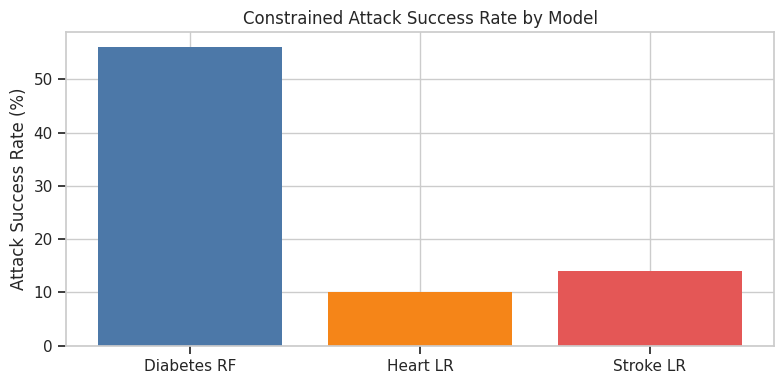


Top perturbed heart features:
 Feature  Mean |Δ|          Interpretation
trestbps      96.4    96.40 raw-unit shift
      cp       1.0 1.00 category-flip rate
   exang       0.2 0.20 category-flip rate
     sex       0.0 0.00 category-flip rate
     Age       0.0     0.00 raw-unit shift
    chol       0.0     0.00 raw-unit shift
     fbs       0.0 0.00 category-flip rate
 restecg       0.0 0.00 category-flip rate

Top perturbed stroke features:
          Feature  Mean |Δ|          Interpretation
avg_glucose_level   77.0143    77.01 raw-unit shift
   smoking_status    0.4286 0.43 category-flip rate
              age    0.0000     0.00 raw-unit shift
           gender    0.0000 0.00 category-flip rate
     hypertension    0.0000 0.00 category-flip rate
    heart_disease    0.0000 0.00 category-flip rate
        work_type    0.0000 0.00 category-flip rate
     ever_married    0.0000 0.00 category-flip rate

Top perturbed diabetes features:
                 Feature  Mean |Δ|       Interpr

In [11]:
def summarise_perturbation(results: List[Dict], feature_names: List[str], constraints: Dict[str, FeatureConstraint]) -> pd.DataFrame:
    successful = [r for r in results if r['success']]
    if not successful:
        return pd.DataFrame(columns=['Feature', 'Mean |Δ|', 'Interpretation'])

    deltas = np.array([r['delta'] for r in successful], dtype=float)
    mean_abs_delta = np.mean(np.abs(deltas), axis=0)

    rows = []
    for i, feat in enumerate(feature_names):
        constraint = constraints[feat]
        interpretation = (
            f"{mean_abs_delta[i]:.2f} category-flip rate"
            if constraint.is_categorical else
            f"{mean_abs_delta[i]:.2f} raw-unit shift"
        )
        rows.append({
            'Feature': feat,
            'Mean |Δ|': round(float(mean_abs_delta[i]), 4),
            'Interpretation': interpretation,
        })

    return pd.DataFrame(rows).sort_values('Mean |Δ|', ascending=False)


def summarise_bound_hits(
    results: List[Dict],
    feature_names: List[str],
    constraints: Dict[str, FeatureConstraint],
    reference_df: pd.DataFrame,
) -> pd.DataFrame:
    successful = [r for r in results if r['success']]
    rows = []
    if not successful:
        return pd.DataFrame(
            columns=['Feature', 'Changed in Successes', 'Lower Hits', 'Upper Hits', 'Observed Range', 'Constraint Range']
        )

    for feat in feature_names:
        constraint = constraints[feat]
        if constraint.is_categorical:
            continue

        changed = [
            r for r in successful
            if float(r['x_adv'][feat]) != float(r['x_orig'][feat])
        ]
        if not changed:
            continue

        lower_hits = 0
        upper_hits = 0
        for r in changed:
            adv_val = float(r['x_adv'][feat])
            if constraint.min_val is not None and np.isclose(adv_val, float(constraint.min_val)):
                lower_hits += 1
            if constraint.max_val is not None and np.isclose(adv_val, float(constraint.max_val)):
                upper_hits += 1

        observed = pd.to_numeric(reference_df[feat], errors='coerce').dropna()
        observed_range = f"[{observed.min():.2f}, {observed.max():.2f}]" if len(observed) else 'n/a'
        constraint_low = constraint.min_val if constraint.min_val is not None else '-inf'
        constraint_high = constraint.max_val if constraint.max_val is not None else 'inf'
        constraint_range = f"[{constraint_low}, {constraint_high}]"

        rows.append({
            'Feature': feat,
            'Changed in Successes': f"{len(changed)}/{len(successful)}",
            'Lower Hits': lower_hits,
            'Upper Hits': upper_hits,
            'Observed Range': observed_range,
            'Constraint Range': constraint_range,
        })

    return pd.DataFrame(rows).sort_values(['Upper Hits', 'Lower Hits', 'Feature'], ascending=[False, False, True])


heart_perturb_df = summarise_perturbation(heart_results, HEART_FEATURES, heart_constraints)
stroke_perturb_df = summarise_perturbation(stroke_results, STROKE_RAW_FEATURES, stroke_constraints)
dia_perturb_df = summarise_perturbation(diabetes_results, DIABETES_FEATURES, diabetes_constraints)

summary_df = pd.DataFrame({
    'Disease': ['Diabetes RF', 'Heart LR', 'Stroke LR'],
    'Attack Method': [
        'HopSkipJump (model-space) + raw projection',
        'Greedy raw-space bound search',
        'Greedy raw-space bound search',
    ],
    'Seeds': [len(diabetes_results), len(heart_results), len(stroke_results)],
    'Successful Flips': [len(dia_success), len(heart_success), len(stroke_success)],
    'ASR (%)': [round(dia_asr, 1), round(heart_asr, 1), round(stroke_asr, 1)],
    'Mean Successful L2': [
        round(float(np.mean(dia_l2_vals)), 4) if dia_l2_vals else np.nan,
        round(float(np.mean(heart_l2_vals)), 4) if heart_l2_vals else np.nan,
        round(float(np.mean(stroke_l2_vals)), 4) if stroke_l2_vals else np.nan,
    ],
})

print(summary_df.to_string(index=False))
print('\nInterpretation notes:')
print('- Cross-disease ASR differences are not apples-to-apples because Diabetes uses HopSkipJump while Heart/Stroke use a greedy raw-space search.')
print('- Mean Successful L2 is in raw feature units, so compare L2 within a disease setup rather than across diseases.')
print('- For Heart and Stroke, inspect the bound-hit diagnostics below before treating successful attacks as clinically plausible.')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(summary_df['Disease'], summary_df['ASR (%)'], color=['#4c78a8', '#f58518', '#e45756'])
ax.set_ylabel('Attack Success Rate (%)')
ax.set_title('Within-Setup Constrained Attack Success Rate by Model')
plt.tight_layout()
plt.show()

heart_bound_df = summarise_bound_hits(heart_results, HEART_FEATURES, heart_constraints, heart_df)
stroke_bound_df = summarise_bound_hits(stroke_results, STROKE_RAW_FEATURES, stroke_constraints, stroke_df)

print('\nTop perturbed heart features:')
print(heart_perturb_df.head(8).to_string(index=False))
print('\nHeart bound-hit diagnostics:')
print(heart_bound_df.to_string(index=False) if not heart_bound_df.empty else 'No mutable numeric heart features changed in successful attacks.')
print('\nTop perturbed stroke features:')
print(stroke_perturb_df.head(8).to_string(index=False))
print('\nStroke bound-hit diagnostics:')
print(stroke_bound_df.to_string(index=False) if not stroke_bound_df.empty else 'No mutable numeric stroke features changed in successful attacks.')
print('\nTop perturbed diabetes features:')
print(dia_perturb_df.head(8).to_string(index=False))


In [12]:
adversarial_artifacts = {
    'diabetes': {
        'results': diabetes_results,
        'feature_names': DIABETES_FEATURES,
        'attack_method': 'HopSkipJump + raw-space clinical projection',
        'asr': dia_asr,
        'mean_l2': float(np.mean(dia_l2_vals)) if dia_l2_vals else None,
    },
    'heart': {
        'results': heart_results,
        'feature_names': HEART_FEATURES,
        'attack_method': 'Greedy constrained attack in raw clinical space',
        'asr': heart_asr,
        'mean_l2': float(np.mean(heart_l2_vals)) if heart_l2_vals else None,
    },
    'stroke': {
        'results': stroke_results,
        'feature_names': STROKE_RAW_FEATURES,
        'attack_method': 'Greedy constrained attack in raw clinical space',
        'asr': stroke_asr,
        'mean_l2': float(np.mean(stroke_l2_vals)) if stroke_l2_vals else None,
    },
}

joblib.dump(adversarial_artifacts, OUTPUT_DIR / 'adversarial_examples.joblib')
print(f"Saved constrained attack artifacts -> {OUTPUT_DIR / 'adversarial_examples.joblib'}")


Saved constrained attack artifacts -> /home/iaminspiredbro/my_projects/xai-health-risk-system/output/adversarial_examples.joblib
